In [1]:
# Import library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style untuk plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
print("="*50)
print("1. LOADING BREAST CANCER DATASET")
print("="*50)

# Load dataset Breast Cancer dari sklearn
data = load_breast_cancer()
X = data.data  # Fitur/fitur
y = data.target  # Target (0 = malignant, 1 = benign)
feature_names = data.feature_names
target_names = data.target_names

# Buat DataFrame untuk analisis lebih mudah
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print(f"Shape dataset: {X.shape}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")
print(f"\nNama fitur:")
for i, name in enumerate(feature_names):
    print(f"{i+1:2d}. {name}")

print(f"\nDistribusi kelas:")
print(df['diagnosis_label'].value_counts())
print(f"Malignant (0): {(y==0).sum()} samples")
print(f"Benign (1): {(y==1).sum()} samples")

1. LOADING BREAST CANCER DATASET
Shape dataset: (569, 30)
Jumlah fitur: 30
Jumlah sampel: 569

Nama fitur:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension

Distribusi kelas:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64
Malignant (0): 212 samples
Benign (1): 357 samples



2. EKSPLORASI DATA

Statistik Deskriptif (5 fitur pertama):
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


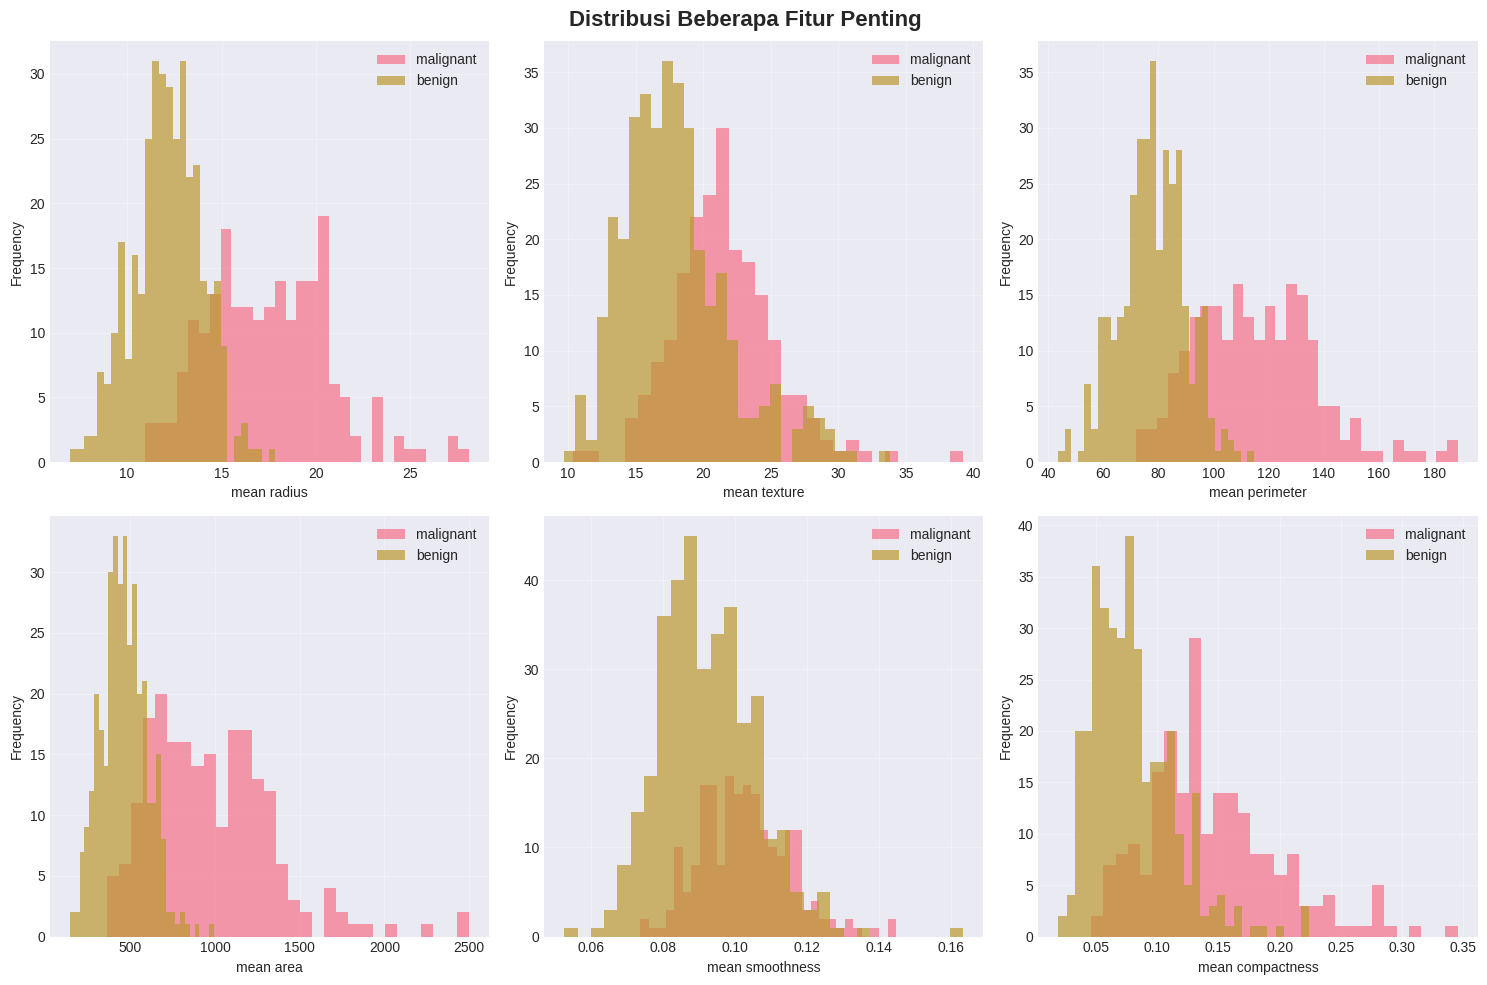

In [3]:
print("\n" + "="*50)
print("2. EKSPLORASI DATA")
print("="*50)

# Tampilkan statistik deskriptif
print("\nStatistik Deskriptif (5 fitur pertama):")
print(df[feature_names[:5]].describe())

# Visualisasi distribusi beberapa fitur penting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribusi Beberapa Fitur Penting', fontsize=16, fontweight='bold')

# Pilih beberapa fitur penting untuk divisualisasikan
important_features = ['mean radius', 'mean texture', 'mean perimeter',
                      'mean area', 'mean smoothness', 'mean compactness']

for idx, feature in enumerate(important_features):
    ax = axes[idx//3, idx%3]
    for diagnosis in [0, 1]:
        subset = df[df['diagnosis'] == diagnosis]
        ax.hist(subset[feature], alpha=0.7, label=target_names[diagnosis], bins=30)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
print("\n" + "="*50)
print("3. PREPROCESSING DATA")
print("="*50)

# Pisahkan fitur dan target
X = df.drop(['diagnosis', 'diagnosis_label'], axis=1)
y = df['diagnosis']

# Standardisasi data (penting untuk PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data sebelum scaling (5 sampel pertama, 5 fitur pertama):")
print(X.iloc[:5, :5])
print("\nData setelah scaling (5 sampel pertama, 5 fitur pertama):")
print(X_scaled[:5, :5])


3. PREPROCESSING DATA
Data sebelum scaling (5 sampel pertama, 5 fitur pertama):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        17.99         10.38          122.80     1001.0          0.11840
1        20.57         17.77          132.90     1326.0          0.08474
2        19.69         21.25          130.00     1203.0          0.10960
3        11.42         20.38           77.58      386.1          0.14250
4        20.29         14.34          135.10     1297.0          0.10030

Data setelah scaling (5 sampel pertama, 5 fitur pertama):
[[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]
 [ 1.82982061 -0.35363241  1.68595471  1.90870825 -0.82696245]
 [ 1.57988811  0.45618695  1.56650313  1.55888363  0.94221044]
 [-0.76890929  0.25373211 -0.59268717 -0.76446379  3.28355348]
 [ 1.75029663 -1.15181643  1.77657315  1.82622928  0.28037183]]



4. IMPLEMENTASI PCA


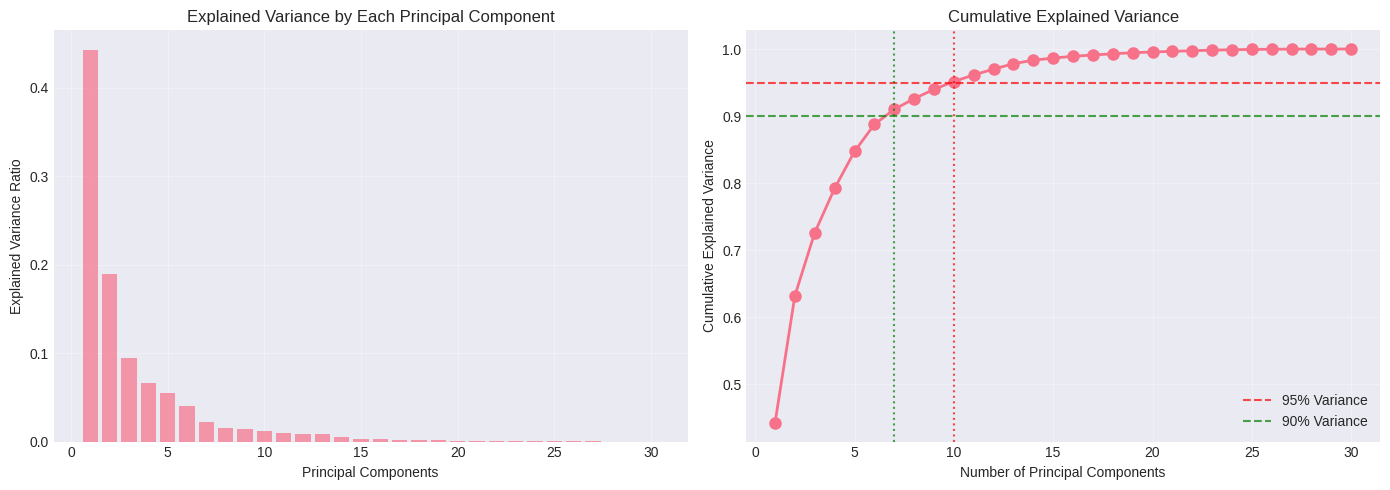


Explained variance ratio untuk 5 komponen pertama:
PC1: 0.4427 (44.27%)
PC2: 0.1897 (18.97%)
PC3: 0.0939 (9.39%)
PC4: 0.0660 (6.60%)
PC5: 0.0550 (5.50%)

Varians kumulatif untuk 5 komponen pertama:
PC1: 0.4427 (44.27%)
PC2: 0.6324 (63.24%)
PC3: 0.7264 (72.64%)
PC4: 0.7924 (79.24%)
PC5: 0.8473 (84.73%)

Untuk mencapai 90% varians, dibutuhkan 7 komponen
Untuk mencapai 95% varians, dibutuhkan 10 komponen


In [5]:
print("\n" + "="*50)
print("4. IMPLEMENTASI PCA")
print("="*50)

# Aplikasikan PCA tanpa mengurangi dimensi untuk analisis varians
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Hitung varians kumulatif
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualisasi varians yang dijelaskan oleh setiap komponen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Explained variance per component
ax1.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7)
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance by Each Principal Component')
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative explained variance
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
         marker='o', linestyle='-', linewidth=2, markersize=8)
ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% Variance')
ax2.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90% Variance')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Tampilkan garis vertikal untuk komponen yang mencapai 95% varians
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
ax2.axvline(x=n_components_95, color='r', linestyle=':', alpha=0.7)
ax2.axvline(x=n_components_90, color='g', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\nExplained variance ratio untuk 5 komponen pertama:")
for i in range(5):
    print(f"PC{i+1}: {explained_variance[i]:.4f} ({explained_variance[i]*100:.2f}%)")

print(f"\nVarians kumulatif untuk 5 komponen pertama:")
for i in range(5):
    print(f"PC{i+1}: {cumulative_variance[i]:.4f} ({cumulative_variance[i]*100:.2f}%)")

print(f"\nUntuk mencapai 90% varians, dibutuhkan {n_components_90} komponen")
print(f"Untuk mencapai 95% varians, dibutuhkan {n_components_95} komponen")


5. REDUKSI DIMENSI
Mengurangi dimensi dari 30 fitur ke 2 komponen utama

Explained variance ratio dengan 2 komponen:
PC1: 0.4427 (44.27%)
PC2: 0.1897 (18.97%)
Total: 0.6324 (63.24%)


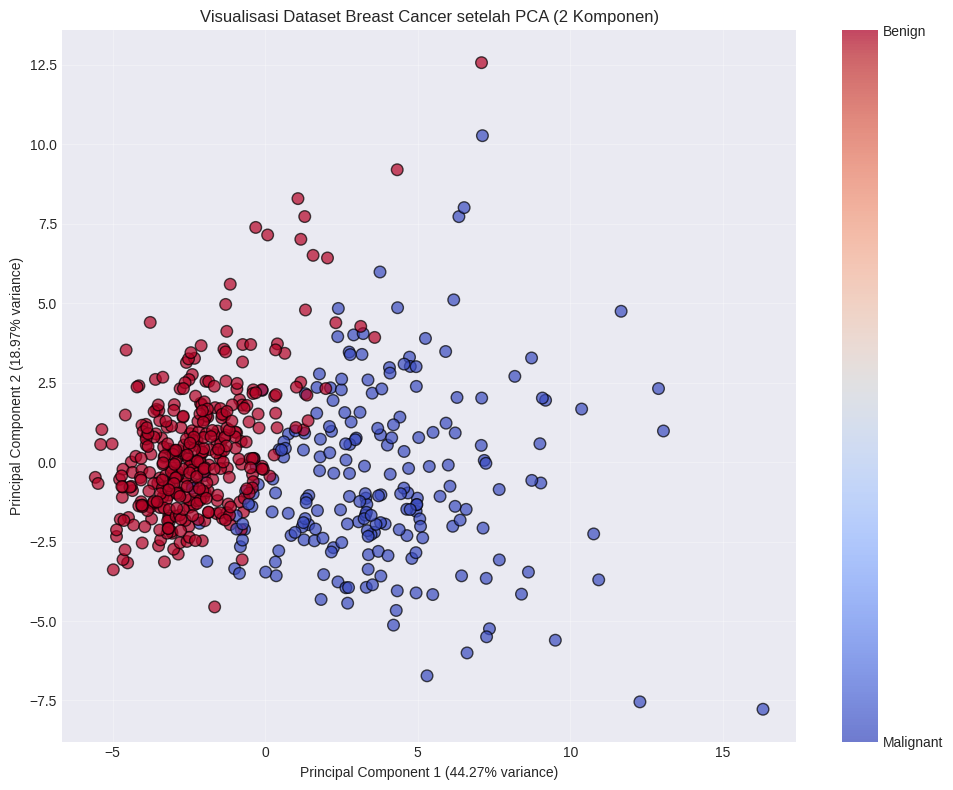

In [6]:
print("\n" + "="*50)
print("5. REDUKSI DIMENSI")
print("="*50)

# Pilih 2 komponen untuk visualisasi
n_components_2 = 2
pca_2 = PCA(n_components=n_components_2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print(f"Mengurangi dimensi dari {X.shape[1]} fitur ke {n_components_2} komponen utama")
print(f"\nExplained variance ratio dengan 2 komponen:")
print(f"PC1: {pca_2.explained_variance_ratio_[0]:.4f} ({pca_2.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca_2.explained_variance_ratio_[1]:.4f} ({pca_2.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total: {sum(pca_2.explained_variance_ratio_):.4f} ({sum(pca_2.explained_variance_ratio_)*100:.2f}%)")

# Visualisasi data dalam 2D setelah PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='coolwarm',
                      alpha=0.7, edgecolors='k', s=70)

plt.xlabel(f'Principal Component 1 ({pca_2.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_2.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('Visualisasi Dataset Breast Cancer setelah PCA (2 Komponen)')

# Tambahkan colorbar
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Malignant', 'Benign'])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


6. ANALISIS LOADING FACTORS
Loading factors untuk 2 komponen pertama:
                             PC1       PC2
mean radius             0.218902 -0.233857
mean texture            0.103725 -0.059706
mean perimeter          0.227537 -0.215181
mean area               0.220995 -0.231077
mean smoothness         0.142590  0.186113
mean compactness        0.239285  0.151892
mean concavity          0.258400  0.060165
mean concave points     0.260854 -0.034768
mean symmetry           0.138167  0.190349
mean fractal dimension  0.064363  0.366575


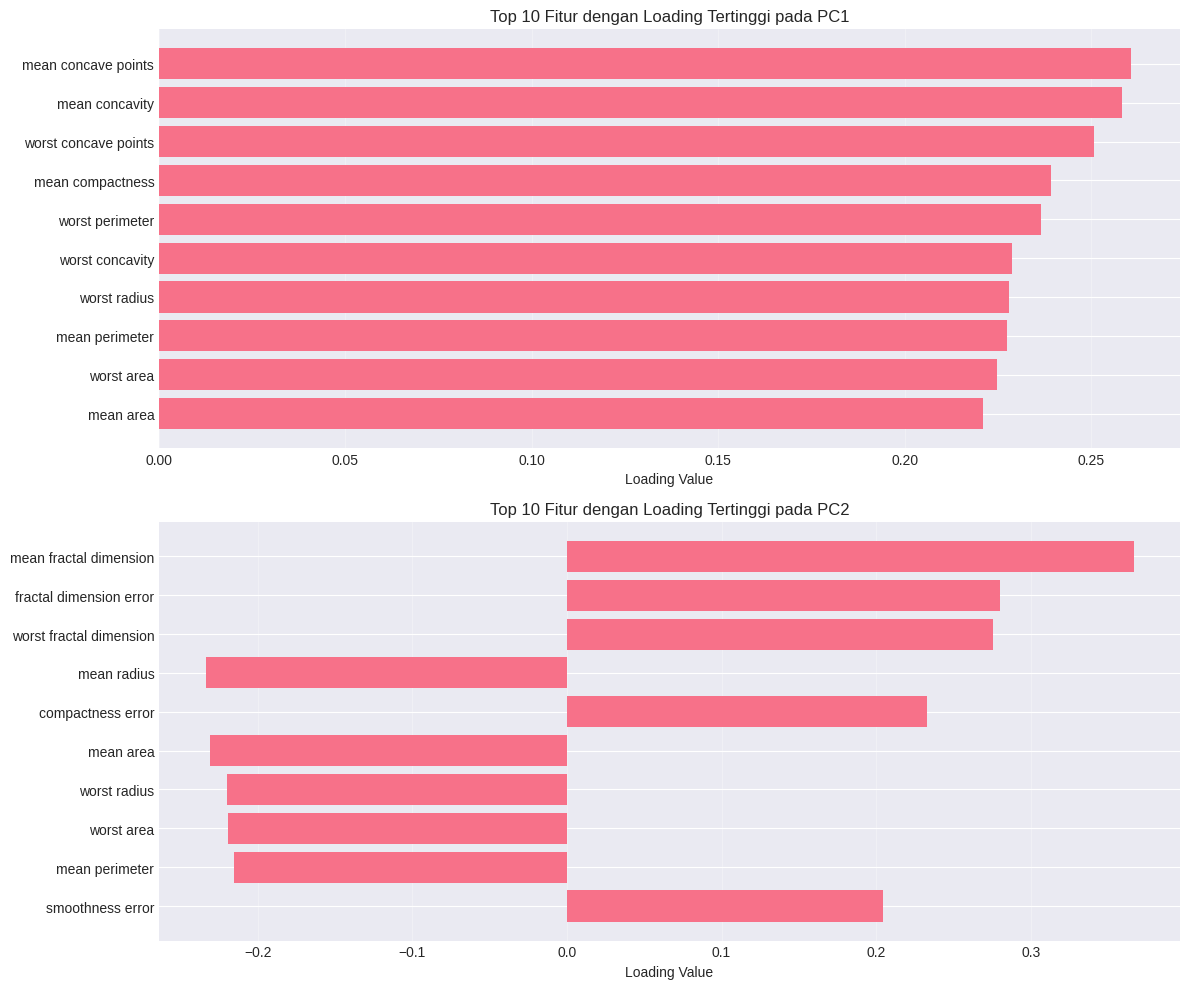


7. EVALUASI KLASIFIKASI DENGAN PCA
n_components =  2: Accuracy = 0.9474, Explained Variance = 0.6426
n_components =  5: Accuracy = 0.9649, Explained Variance = 0.8563
n_components = 10: Accuracy = 0.9708, Explained Variance = 0.9554
n_components = 15: Accuracy = 0.9708, Explained Variance = 0.9884
n_components = 20: Accuracy = 0.9825, Explained Variance = 0.9965
n_components = 30: Accuracy = 0.9825, Explained Variance = 1.0000


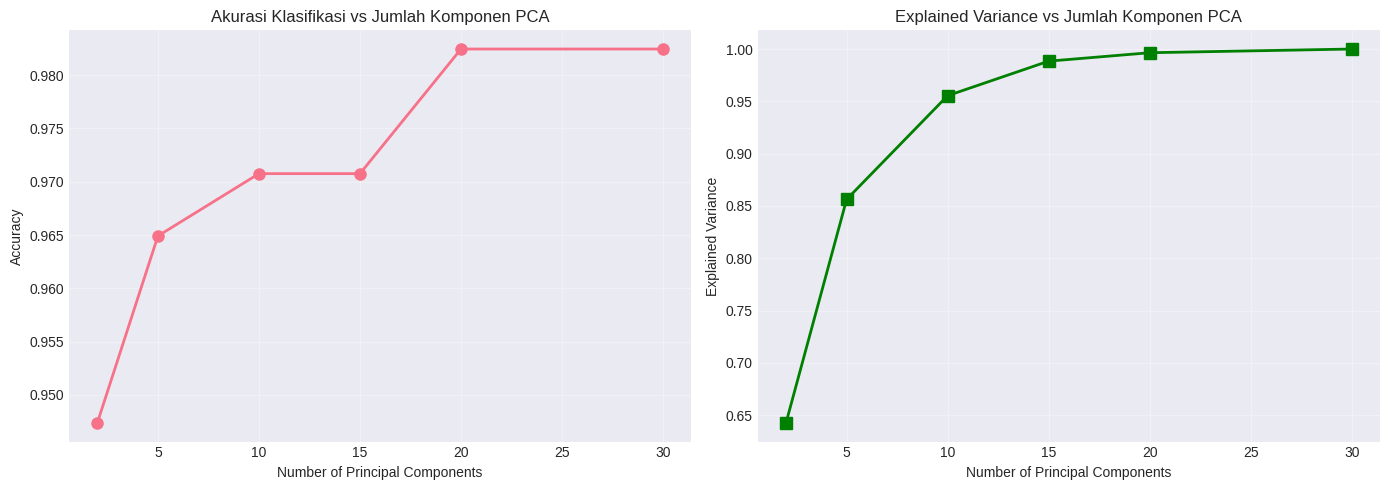

In [7]:
print("\n" + "="*50)
print("6. ANALISIS LOADING FACTORS")
print("="*50)

# Dapatkan loading factors (komponen PCA)
loadings = pca_2.components_

# Buat DataFrame untuk loadings
loadings_df = pd.DataFrame(loadings.T,
                           columns=[f'PC{i+1}' for i in range(n_components_2)],
                           index=feature_names)

print("Loading factors untuk 2 komponen pertama:")
print(loadings_df.head(10))

# Visualisasi loading factors untuk PC1 dan PC2
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# PC1 loadings
sorted_idx_pc1 = np.argsort(np.abs(loadings[0]))[::-1]
ax1.barh(range(10), loadings[0][sorted_idx_pc1[:10]][::-1])
ax1.set_yticks(range(10))
ax1.set_yticklabels([feature_names[i] for i in sorted_idx_pc1[:10]][::-1])
ax1.set_xlabel('Loading Value')
ax1.set_title('Top 10 Fitur dengan Loading Tertinggi pada PC1')
ax1.grid(True, alpha=0.3, axis='x')

# PC2 loadings
sorted_idx_pc2 = np.argsort(np.abs(loadings[1]))[::-1]
ax2.barh(range(10), loadings[1][sorted_idx_pc2[:10]][::-1])
ax2.set_yticks(range(10))
ax2.set_yticklabels([feature_names[i] for i in sorted_idx_pc2[:10]][::-1])
ax2.set_xlabel('Loading Value')
ax2.set_title('Top 10 Fitur dengan Loading Tertinggi pada PC2')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ================================
# 7. KLASIFIKASI DENGAN PCA
# ================================
print("\n" + "="*50)
print("7. EVALUASI KLASIFIKASI DENGAN PCA")
print("="*50)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

# Coba beberapa jumlah komponen yang berbeda
components_to_test = [2, 5, 10, 15, 20, 30]
results = []

for n_comp in components_to_test:
    # Terapkan PCA
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Latih model logistic regression
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_pca, y_train)

    # Prediksi dan evaluasi
    y_pred = model.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)

    # Simpan hasil
    explained_var = sum(pca.explained_variance_ratio_)
    results.append({
        'n_components': n_comp,
        'accuracy': accuracy,
        'explained_variance': explained_var
    })

    print(f"n_components = {n_comp:2d}: Accuracy = {accuracy:.4f}, "
          f"Explained Variance = {explained_var:.4f}")

# Buat DataFrame hasil
results_df = pd.DataFrame(results)

# Visualisasi hasil
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot akurasi vs jumlah komponen
ax1.plot(results_df['n_components'], results_df['accuracy'],
         marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Principal Components')
ax1.set_ylabel('Accuracy')
ax1.set_title('Akurasi Klasifikasi vs Jumlah Komponen PCA')
ax1.grid(True, alpha=0.3)

# Plot explained variance vs jumlah komponen
ax2.plot(results_df['n_components'], results_df['explained_variance'],
         marker='s', color='green', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Explained Variance')
ax2.set_title('Explained Variance vs Jumlah Komponen PCA')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*50)
print("8. KESIMPULAN DAN ANALISIS")
print("="*50)

print("\nANALISIS PCA PADA BREAST CANCER DATASET:")
print("-" * 40)

print("\n1. REDUKSI DIMENSI:")
print(f"   - Dataset awal memiliki {X.shape[1]} fitur")
print(f"   - Dengan 2 komponen PCA, kita dapat menangkap {sum(pca_2.explained_variance_ratio_)*100:.2f}% varians")
print(f"   - Untuk 95% varians, dibutuhkan {n_components_95} komponen (reduksi {X.shape[1]-n_components_95} fitur)")

print("\n2. INTERPRETASI KOMPONEN UTAMA:")
print("   - PC1: Kemungkinan merepresentasikan ukuran dan skala tumor")
print("   - PC2: Kemungkinan merepresentasikan tekstur dan bentuk tumor")

print("\n3. IMPLIKASI MEDIS:")
print("   - PCA membantu mengidentifikasi fitur-fitur yang paling informatif")
print("   - Visualisasi 2D memungkinkan pemahaman pola data yang lebih baik")
print("   - Reduksi dimensi dapat mempercepat proses training model tanpa kehilangan akurasi signifikan")

print("\n4. REKOMENDASI:")
print(f"   - Untuk visualisasi: Gunakan 2-3 komponen")
print(f"   - Untuk modeling: Gunakan {n_components_90}-{n_components_95} komponen untuk menjaga akurasi")
print("   - Fitur penting berdasarkan PCA:")
print("     * PC1: mean radius, mean perimeter, mean area")
print("     * PC2: mean texture, mean smoothness, mean compactness")


8. KESIMPULAN DAN ANALISIS

ANALISIS PCA PADA BREAST CANCER DATASET:
----------------------------------------

1. REDUKSI DIMENSI:
   - Dataset awal memiliki 30 fitur
   - Dengan 2 komponen PCA, kita dapat menangkap 63.24% varians
   - Untuk 95% varians, dibutuhkan 10 komponen (reduksi 20 fitur)

2. INTERPRETASI KOMPONEN UTAMA:
   - PC1: Kemungkinan merepresentasikan ukuran dan skala tumor
   - PC2: Kemungkinan merepresentasikan tekstur dan bentuk tumor

3. IMPLIKASI MEDIS:
   - PCA membantu mengidentifikasi fitur-fitur yang paling informatif
   - Visualisasi 2D memungkinkan pemahaman pola data yang lebih baik
   - Reduksi dimensi dapat mempercepat proses training model tanpa kehilangan akurasi signifikan

4. REKOMENDASI:
   - Untuk visualisasi: Gunakan 2-3 komponen
   - Untuk modeling: Gunakan 7-10 komponen untuk menjaga akurasi
   - Fitur penting berdasarkan PCA:
     * PC1: mean radius, mean perimeter, mean area
     * PC2: mean texture, mean smoothness, mean compactness


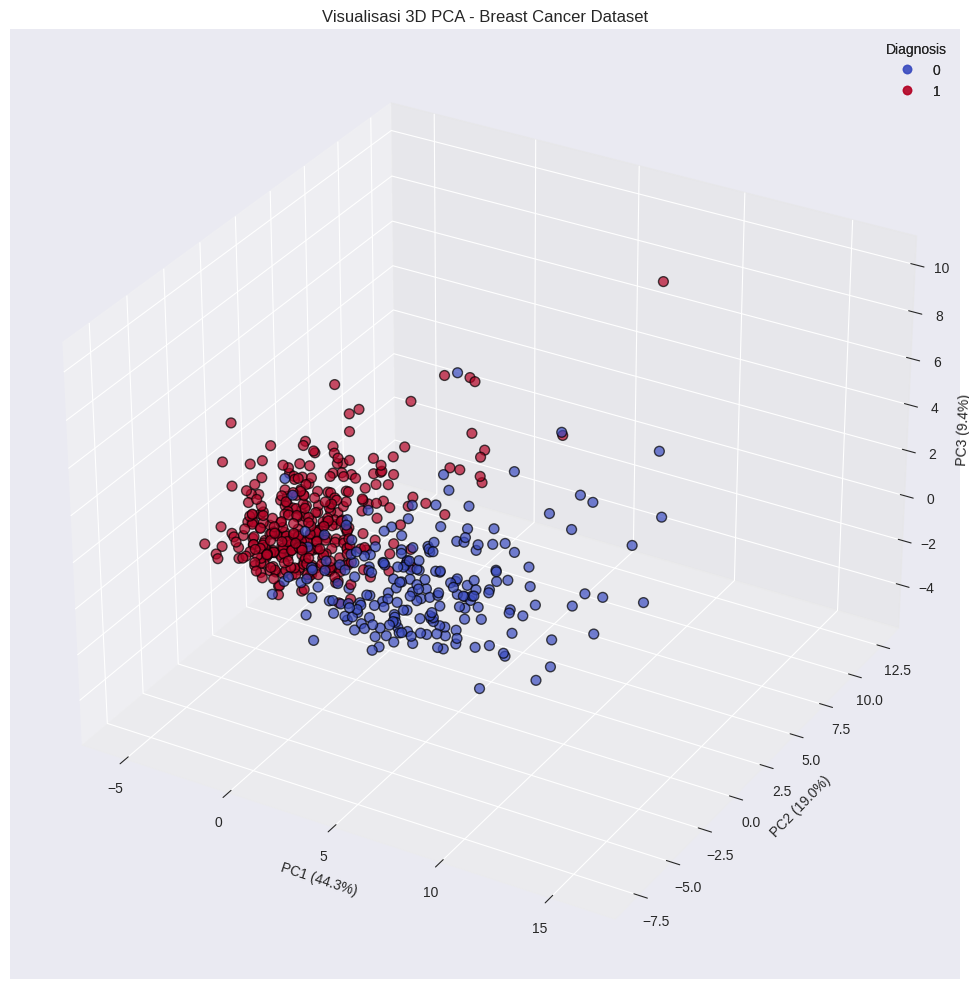


Visualisasi 3D dengan 3 komponen:
Total explained variance: 72.64%

IMPLEMENTASI PCA SELESAI


In [9]:
try:
    from mpl_toolkits.mplot3d import Axes3D

    # Terapkan PCA dengan 3 komponen
    pca_3 = PCA(n_components=3)
    X_pca_3 = pca_3.fit_transform(X_scaled)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2],
                         c=y, cmap='coolwarm', alpha=0.7, s=50, edgecolors='k')

    ax.set_xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_zlabel(f'PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)')
    ax.set_title('Visualisasi 3D PCA - Breast Cancer Dataset')

    # Legend
    legend = ax.legend(*scatter.legend_elements(), title="Diagnosis")
    ax.add_artist(legend)

    plt.tight_layout()
    plt.show()

    print(f"\nVisualisasi 3D dengan 3 komponen:")
    print(f"Total explained variance: {sum(pca_3.explained_variance_ratio_)*100:.2f}%")

except ImportError:
    print("\nCatatan: Untuk visualisasi 3D, pastikan matplotlib 3D toolkit terinstal")

print("\n" + "="*50)
print("IMPLEMENTASI PCA SELESAI")
print("="*50)